# 気温データの特徴量抽出
## 概要
作成した特徴量まとめ

- 快適温度からの差
$$
X_{new} =  ( T_t - \bar{T}_t )^2
$$

- 気温変化
$$
X_{new} = |\Delta T_t|
$$

- 冷暖房需要
$$
X_{new} =
\max(T_t-\bar T,0)
$$

$$
X_{new} =
\max(\bar T - T_t,0)
$$

In [1]:
# Shared raw data in repository; generated data in this study
from pathlib import Path
import sys

REPO_ROOT = next(
    (p for p in (Path.cwd(), *Path.cwd().parents)
     if (p / "setup-env.ps1").is_file() and (p / "study_with_me").is_dir()),
    None,
)
if REPO_ROOT is None:
    raise RuntimeError("Run this notebook from inside jepx-data-analytics.")
PROJECT_DIR = REPO_ROOT / "study_with_me"
RAW_DATA_DIR = REPO_ROOT / "data" / "raw"
PROJECT_DATA_DIR = PROJECT_DIR / "data"
if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import scipy
import sklearn
import statsmodels
import seaborn

print("numpy:", np.__version__)
print("pandas:", pd.__version__)
print("matplotlib", matplotlib.__version__)
print("scipy:", scipy.__version__)
print("sklearn:", sklearn.__version__)
print("statsmodels:", statsmodels.__version__)
print("seaborn:", seaborn.__version__)

numpy: 2.4.2
pandas: 3.0.1
matplotlib 3.10.8
scipy: 1.17.1
sklearn: 1.8.0
statsmodels: 0.14.6
seaborn: 0.13.2


# 1week

# 快適温度からの差

新しい説明変数として快適温度帯からの逸脱を考える
$$
X_{new} = ( T_t - \bar{T}_t )^2
$$

一旦簡単に
$$
\hat{T}_{\text{適温}} = \bar{T}_t
$$

In [2]:
weekly_base = pd.read_csv((PROJECT_DATA_DIR / "processed/electricity/weekly_temp.csv"))
weekly_base["datetime"] = pd.to_datetime(weekly_base["datetime"])

weekly_base = weekly_base.set_index("datetime")
weekly_base = weekly_base.asfreq("W")

weekly_base.head()

,tokyo_price,log_tokyo_price,temp,tmin,tmax
datetime,,,,,
2021-04-04,5.795625,1.757103,18.000000,15.300000,21.700000
2021-04-11,6.433869,1.861576,11.957143,7.857143,16.500000
2021-04-18,7.525089,2.018243,14.400000,9.957143,18.557143
2021-04-25,6.892857,1.930486,16.271429,10.914286,22.185714
2021-05-02,7.954732,2.073767,16.457143,12.000000,21.071429


Correlation: -0.029272437003641363


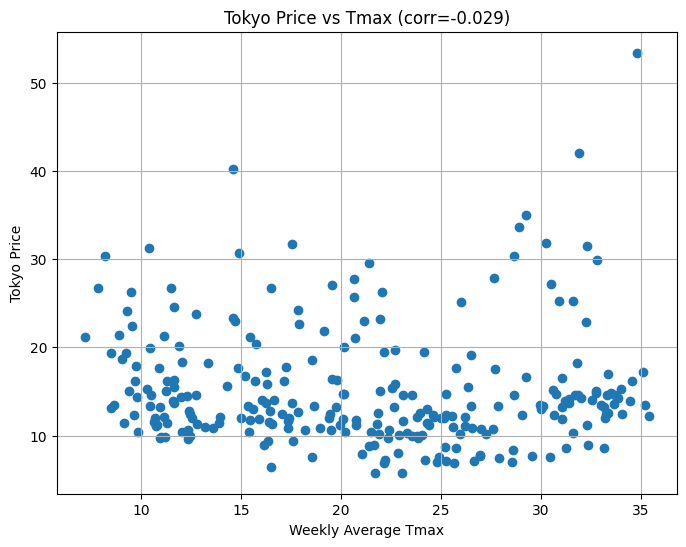

In [3]:
# 相関係数
corr = weekly_base["tokyo_price"].corr(weekly_base["tmax"])

print("Correlation:", corr)

# 散布図
plt.figure(figsize=(8, 6))

plt.scatter(weekly_base["tmax"], weekly_base["tokyo_price"])

plt.xlabel("Weekly Average Tmax")
plt.ylabel("Tokyo Price")
plt.title(f"Tokyo Price vs Tmax (corr={corr:.3f})")

plt.grid(True)

plt.show()

- 春秋 → 安い
- 夏 → 高い
- 冬 → 高い

In [4]:
# その時点までの平均気温
weekly_base["temp_mean_past"] = weekly_base["temp"].expanding().mean()

# 平均からの乖離
weekly_base["temp_centered"] = weekly_base["temp"] - weekly_base["temp_mean_past"]

# 二乗
weekly_base["temp_centered_sq"] = weekly_base["temp_centered"] ** 2

weekly_base.head()

,tokyo_price,log_tokyo_price,temp,tmin,tmax,temp_mean_past,temp_centered,temp_centered_sq
datetime,,,,,,,,
2021-04-04,5.795625,1.757103,18.000000,15.300000,21.700000,18.000000,0.000000,0.000000
2021-04-11,6.433869,1.861576,11.957143,7.857143,16.500000,14.978571,-3.021429,9.129031
2021-04-18,7.525089,2.018243,14.400000,9.957143,18.557143,14.785714,-0.385714,0.148776
2021-04-25,6.892857,1.930486,16.271429,10.914286,22.185714,15.157143,1.114286,1.241633
2021-05-02,7.954732,2.073767,16.457143,12.000000,21.071429,15.417143,1.040000,1.081600


Correlation: 0.11511784231310199


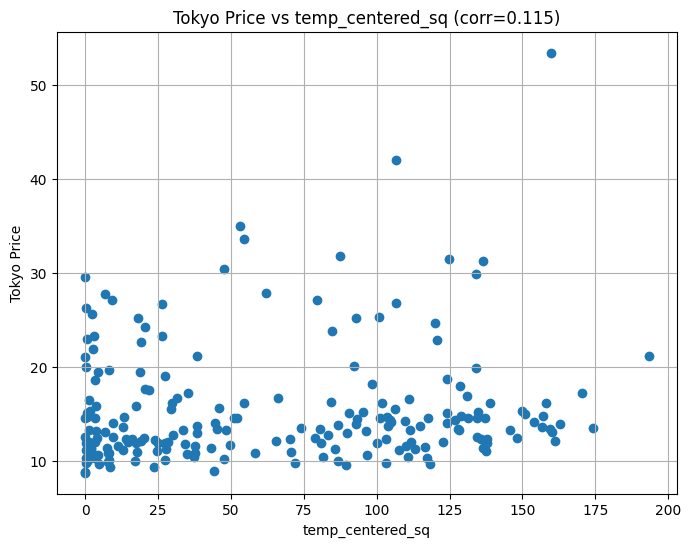

In [5]:
# 最初の年度を取得
first_year = weekly_base.index.year.min()

# 最初の年度を除外
plot_df = weekly_base.loc[f"{first_year + 1}-04-01" :]

# 相関係数
corr = plot_df["tokyo_price"].corr(plot_df["temp_centered_sq"])

print("Correlation:", corr)

# 散布図
plt.figure(figsize=(8, 6))

plt.scatter(plot_df["temp_centered_sq"], plot_df["tokyo_price"])

plt.xlabel("temp_centered_sq")
plt.ylabel("Tokyo Price")

plt.title(f"Tokyo Price vs temp_centered_sq (corr={corr:.3f})")

plt.grid(True)

plt.show()

価格が比較的低温で安定し、高温になると価格が上がる傾向がある

## 気温変化
> スパイクに効きそうな特徴量

電力市場では

- 契約
- 需給予測
- 発電計画

の遅れがあるので、ラグを入れるのは自然
$$
X_{new} = |\Delta T_t|
$$

In [6]:
weekly_base["temp_diff"] = weekly_base["temp"].diff().abs()
weekly_base.head()

,tokyo_price,log_tokyo_price,temp,tmin,tmax,temp_mean_past,temp_centered,temp_centered_sq,temp_diff
datetime,,,,,,,,,
2021-04-04,5.795625,1.757103,18.000000,15.300000,21.700000,18.000000,0.000000,0.000000,NaN
2021-04-11,6.433869,1.861576,11.957143,7.857143,16.500000,14.978571,-3.021429,9.129031,6.042857
2021-04-18,7.525089,2.018243,14.400000,9.957143,18.557143,14.785714,-0.385714,0.148776,2.442857
2021-04-25,6.892857,1.930486,16.271429,10.914286,22.185714,15.157143,1.114286,1.241633,1.871429
2021-05-02,7.954732,2.073767,16.457143,12.000000,21.071429,15.417143,1.040000,1.081600,0.185714


In [7]:
weekly_base.tail()

,tokyo_price,log_tokyo_price,temp,tmin,tmax,temp_mean_past,temp_centered,temp_centered_sq,temp_diff
datetime,,,,,,,,,
2026-03-08,10.822143,2.381594,9.471429,6.142857,13.600000,17.099557,-7.628128,58.188344,2.800000
2026-03-15,13.878214,2.630320,7.742857,4.200000,11.614286,17.063431,-9.320574,86.873093,1.728571
2026-03-22,16.710030,2.816009,11.428571,8.071429,15.214286,17.041758,-5.613187,31.507866,3.685714
2026-03-29,15.895655,2.766046,12.828571,10.042857,16.328571,17.025616,-4.197044,17.615181,1.400000
2026-04-05,18.612292,2.923822,15.171429,11.914286,18.542857,17.018539,-1.847110,3.411816,2.342857


Correlation: 0.014639236047393318


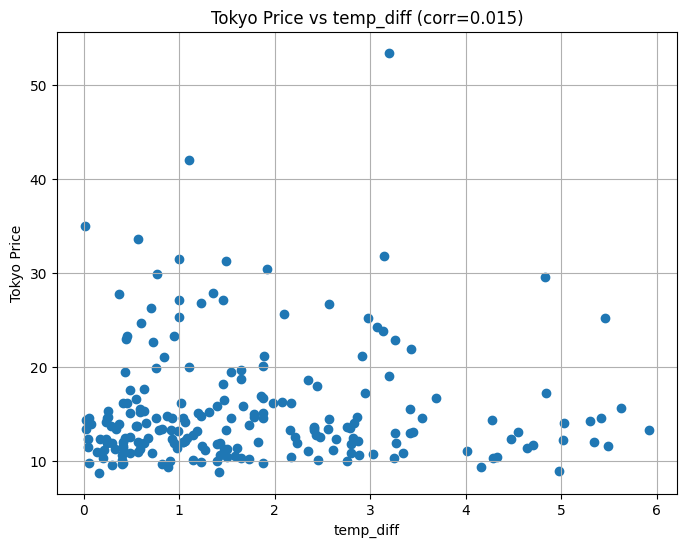

In [8]:
# 最初の年度を取得
first_year = weekly_base.index.year.min()

# 最初の年度を除外
plot_df = weekly_base.loc[f"{first_year + 1}-04-01" :]

# 相関係数
corr = plot_df["tokyo_price"].corr(plot_df["temp_diff"])
print("Correlation:", corr)
# 散布図
plt.figure(figsize=(8, 6))
plt.scatter(plot_df["temp_diff"], plot_df["tokyo_price"])
plt.xlabel("temp_diff")
plt.ylabel("Tokyo Price")
plt.title(f"Tokyo Price vs temp_diff (corr={corr:.3f})")
plt.grid(True)
plt.show()

In [9]:
# データ保存
weekly_base.head()

,tokyo_price,log_tokyo_price,temp,tmin,tmax,temp_mean_past,temp_centered,temp_centered_sq,temp_diff
datetime,,,,,,,,,
2021-04-04,5.795625,1.757103,18.000000,15.300000,21.700000,18.000000,0.000000,0.000000,NaN
2021-04-11,6.433869,1.861576,11.957143,7.857143,16.500000,14.978571,-3.021429,9.129031,6.042857
2021-04-18,7.525089,2.018243,14.400000,9.957143,18.557143,14.785714,-0.385714,0.148776,2.442857
2021-04-25,6.892857,1.930486,16.271429,10.914286,22.185714,15.157143,1.114286,1.241633,1.871429
2021-05-02,7.954732,2.073767,16.457143,12.000000,21.071429,15.417143,1.040000,1.081600,0.185714


In [10]:
weekly_base.tail()

,tokyo_price,log_tokyo_price,temp,tmin,tmax,temp_mean_past,temp_centered,temp_centered_sq,temp_diff
datetime,,,,,,,,,
2026-03-08,10.822143,2.381594,9.471429,6.142857,13.600000,17.099557,-7.628128,58.188344,2.800000
2026-03-15,13.878214,2.630320,7.742857,4.200000,11.614286,17.063431,-9.320574,86.873093,1.728571
2026-03-22,16.710030,2.816009,11.428571,8.071429,15.214286,17.041758,-5.613187,31.507866,3.685714
2026-03-29,15.895655,2.766046,12.828571,10.042857,16.328571,17.025616,-4.197044,17.615181,1.400000
2026-04-05,18.612292,2.923822,15.171429,11.914286,18.542857,17.018539,-1.847110,3.411816,2.342857


# 冷暖房需要
ある気温を超えてくると暖房を利用するようになり需要が増すといった性質を考慮するために、快適温度帯からの逸脱を正負で分けて特徴量を作ることも考えられる
$$
X_{new} =
\max(T_t-\bar T,0)
$$

$$
X_{new} =
\max(\bar T - T_t,0)
$$

In [11]:
temp_mean = weekly_base["temp"].mean()

weekly_base["temp_hot"] = np.maximum(weekly_base["temp"] - temp_mean, 0)

weekly_base["temp_cold"] = np.maximum(temp_mean - weekly_base["temp"], 0)

weekly_base.head()

,tokyo_price,log_tokyo_price,temp,tmin,tmax,temp_mean_past,temp_centered,temp_centered_sq,temp_diff,temp_hot,temp_cold
datetime,,,,,,,,,,,
2021-04-04,5.795625,1.757103,18.000000,15.300000,21.700000,18.000000,0.000000,0.000000,NaN,0.981461,0.000000
2021-04-11,6.433869,1.861576,11.957143,7.857143,16.500000,14.978571,-3.021429,9.129031,6.042857,0.000000,5.061396
2021-04-18,7.525089,2.018243,14.400000,9.957143,18.557143,14.785714,-0.385714,0.148776,2.442857,0.000000,2.618539
2021-04-25,6.892857,1.930486,16.271429,10.914286,22.185714,15.157143,1.114286,1.241633,1.871429,0.000000,0.747110
2021-05-02,7.954732,2.073767,16.457143,12.000000,21.071429,15.417143,1.040000,1.081600,0.185714,0.000000,0.561396


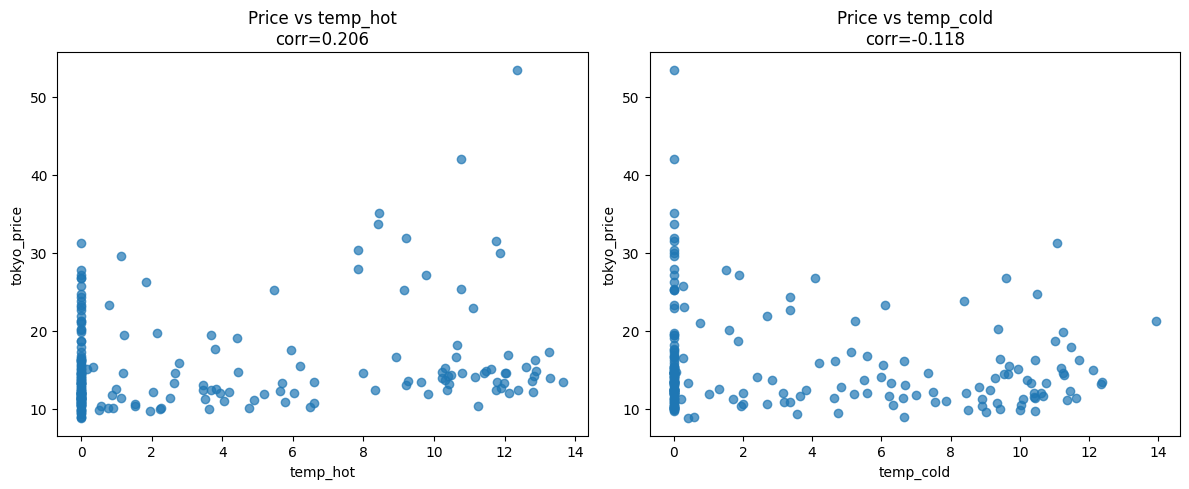

In [12]:
# 最初の年度を取得
first_year = weekly_base.index.year.min()

# 最初の年度を除外
plot_df = weekly_base.loc[f"{first_year + 1}-04-01" :]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 暑さ側
axes[0].scatter(plot_df["temp_hot"], plot_df["tokyo_price"], alpha=0.7)

corr_hot = plot_df["temp_hot"].corr(plot_df["tokyo_price"])

axes[0].set_title(f"Price vs temp_hot\ncorr={corr_hot:.3f}")

axes[0].set_xlabel("temp_hot")
axes[0].set_ylabel("tokyo_price")

# 寒さ側
axes[1].scatter(plot_df["temp_cold"], plot_df["tokyo_price"], alpha=0.7)

corr_cold = plot_df["temp_cold"].corr(plot_df["tokyo_price"])

axes[1].set_title(f"Price vs temp_cold\ncorr={corr_cold:.3f}")

axes[1].set_xlabel("temp_cold")
axes[1].set_ylabel("tokyo_price")

plt.tight_layout()
plt.show()

In [13]:
plot_df.head()

,tokyo_price,log_tokyo_price,temp,tmin,tmax,temp_mean_past,temp_centered,temp_centered_sq,temp_diff,temp_hot,temp_cold
datetime,,,,,,,,,,,
2022-04-03,23.296071,3.148285,10.900000,7.500000,14.614286,16.027224,-5.127224,26.288423,0.942857,0.0,6.118539
2022-04-10,21.897768,3.086385,14.328571,10.057143,19.157143,15.995767,-1.667196,2.779542,3.428571,0.0,2.689967
2022-04-17,20.026012,2.997032,15.428571,11.428571,20.157143,15.985455,-0.556883,0.310119,1.100000,0.0,1.589967
2022-04-24,21.039256,3.046390,16.271429,12.528571,20.728571,15.990561,0.280867,0.078886,0.842857,0.0,0.747110
2022-05-01,22.971786,3.134267,16.714286,13.042857,21.171429,16.003258,0.711028,0.505560,0.442857,0.0,0.304253


<Axes: xlabel='is_spike', ylabel='temp_hot'>

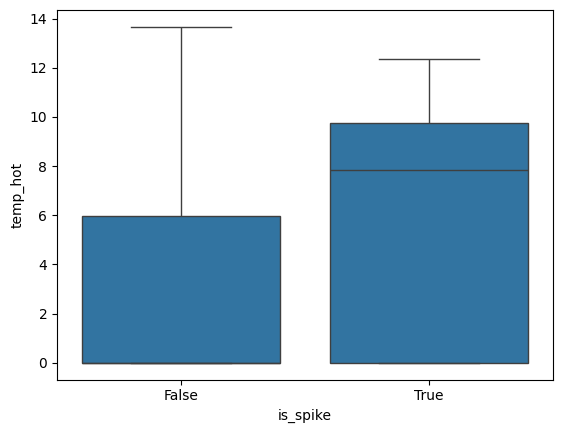

In [14]:
import seaborn as sns

plot_df["is_spike"] = plot_df["tokyo_price"] >= 25
sns.boxplot(x="is_spike", y="temp_hot", data=plot_df)

## まとめ

In [15]:
weekly_base.head()

,tokyo_price,log_tokyo_price,temp,tmin,tmax,temp_mean_past,temp_centered,temp_centered_sq,temp_diff,temp_hot,temp_cold
datetime,,,,,,,,,,,
2021-04-04,5.795625,1.757103,18.000000,15.300000,21.700000,18.000000,0.000000,0.000000,NaN,0.981461,0.000000
2021-04-11,6.433869,1.861576,11.957143,7.857143,16.500000,14.978571,-3.021429,9.129031,6.042857,0.000000,5.061396
2021-04-18,7.525089,2.018243,14.400000,9.957143,18.557143,14.785714,-0.385714,0.148776,2.442857,0.000000,2.618539
2021-04-25,6.892857,1.930486,16.271429,10.914286,22.185714,15.157143,1.114286,1.241633,1.871429,0.000000,0.747110
2021-05-02,7.954732,2.073767,16.457143,12.000000,21.071429,15.417143,1.040000,1.081600,0.185714,0.000000,0.561396


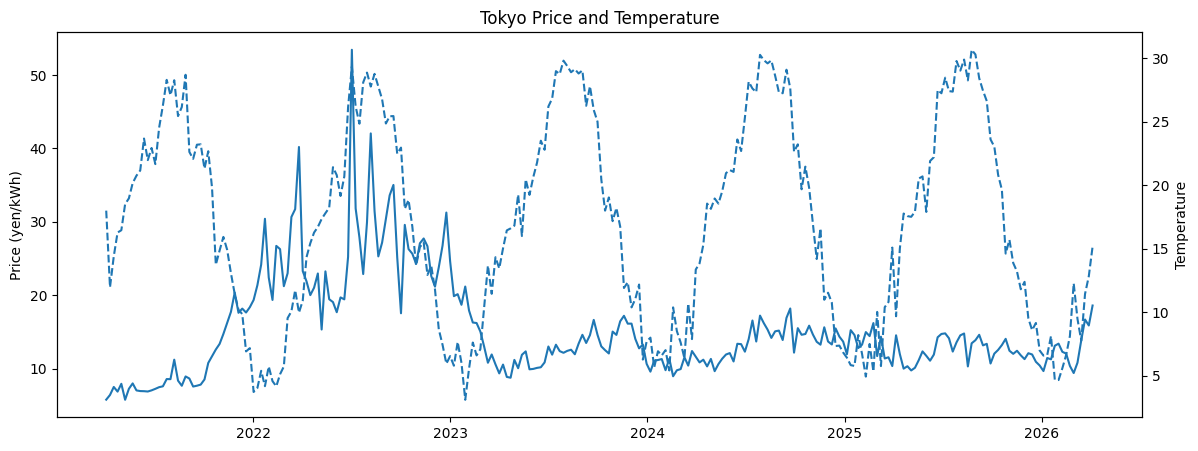

In [16]:
fig, ax1 = plt.subplots(figsize=(14, 5))

# 電力価格
ax1.plot(weekly_base.index, weekly_base["tokyo_price"], label="Tokyo Price")

ax1.set_ylabel("Price (yen/kWh)")

# 気温
ax2 = ax1.twinx()

ax2.plot(weekly_base.index, weekly_base["temp"], linestyle="--", label="Temperature")

ax2.set_ylabel("Temperature")

plt.title("Tokyo Price and Temperature")
plt.show()

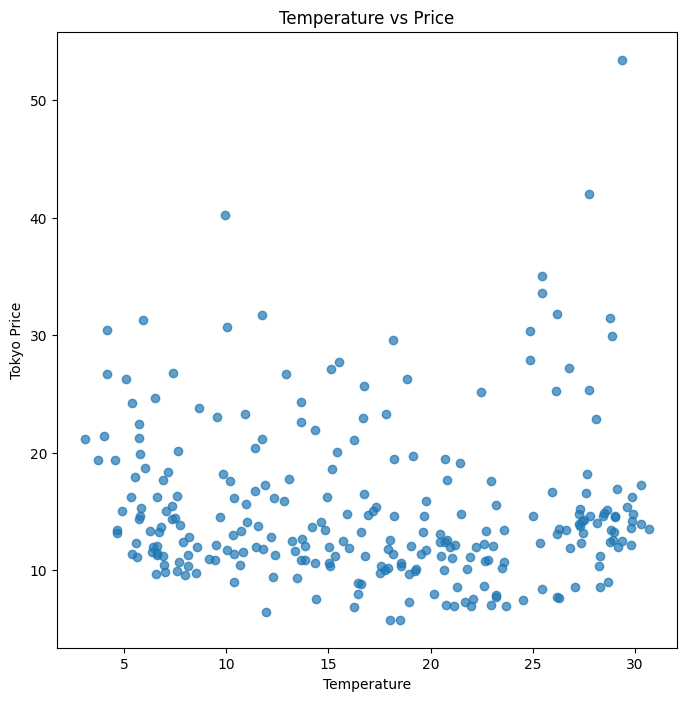

In [17]:
fig, ax = plt.subplots(figsize=(8, 8))

ax.scatter(weekly_base["temp"], weekly_base["tokyo_price"], alpha=0.7)

ax.set_xlabel("Temperature")
ax.set_ylabel("Tokyo Price")

ax.set_title("Temperature vs Price")

plt.show()

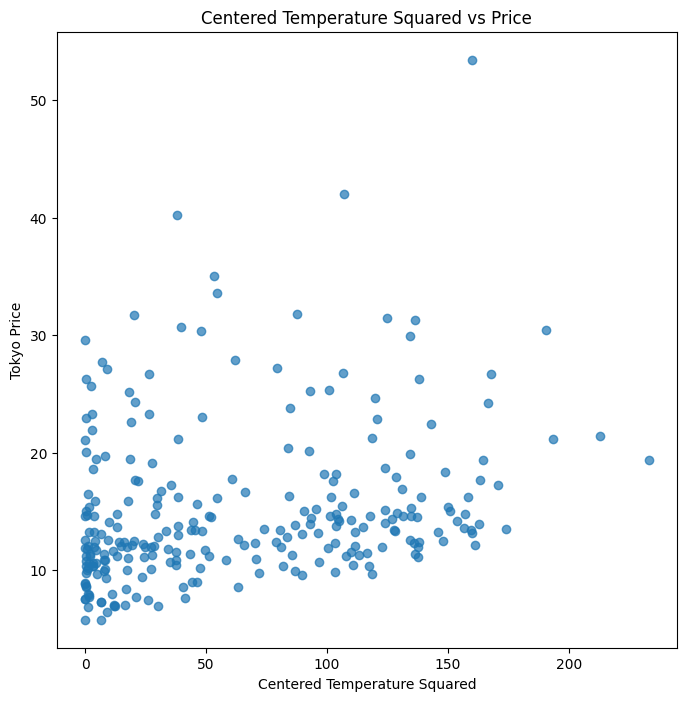

In [18]:
fig, ax = plt.subplots(figsize=(8, 8))

ax.scatter(weekly_base["temp_centered_sq"], weekly_base["tokyo_price"], alpha=0.7)

ax.set_xlabel("Centered Temperature Squared")
ax.set_ylabel("Tokyo Price")

ax.set_title("Centered Temperature Squared vs Price")

plt.show()

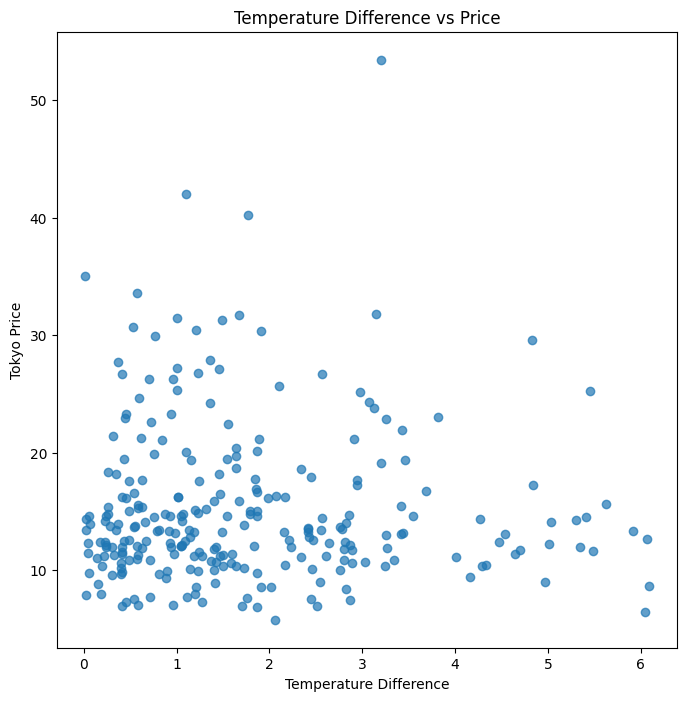

In [19]:
fig, ax = plt.subplots(figsize=(8, 8))

ax.scatter(weekly_base["temp_diff"], weekly_base["tokyo_price"], alpha=0.7)

ax.set_xlabel("Temperature Difference")
ax.set_ylabel("Tokyo Price")

ax.set_title("Temperature Difference vs Price")

plt.show()

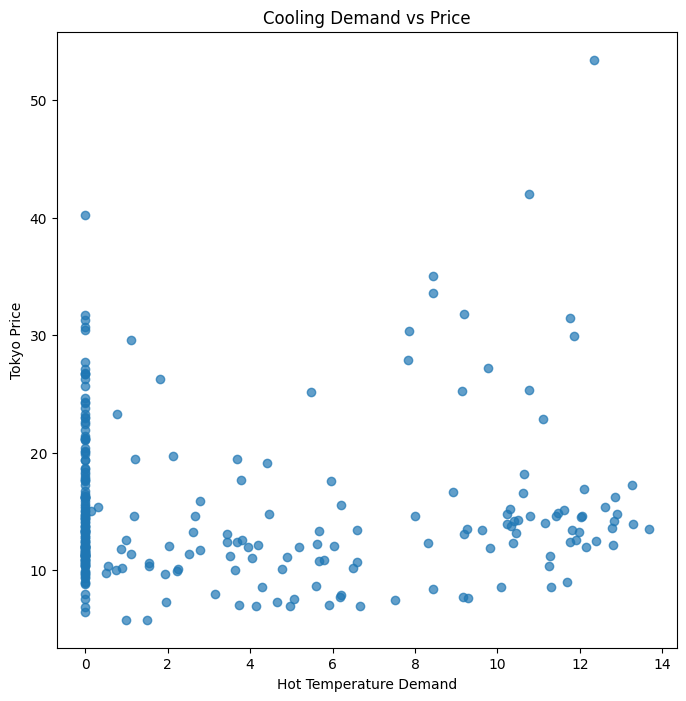

In [20]:
fig, ax = plt.subplots(figsize=(8, 8))

ax.scatter(weekly_base["temp_hot"], weekly_base["tokyo_price"], alpha=0.7)

ax.set_xlabel("Hot Temperature Demand")
ax.set_ylabel("Tokyo Price")

ax.set_title("Cooling Demand vs Price")

plt.show()

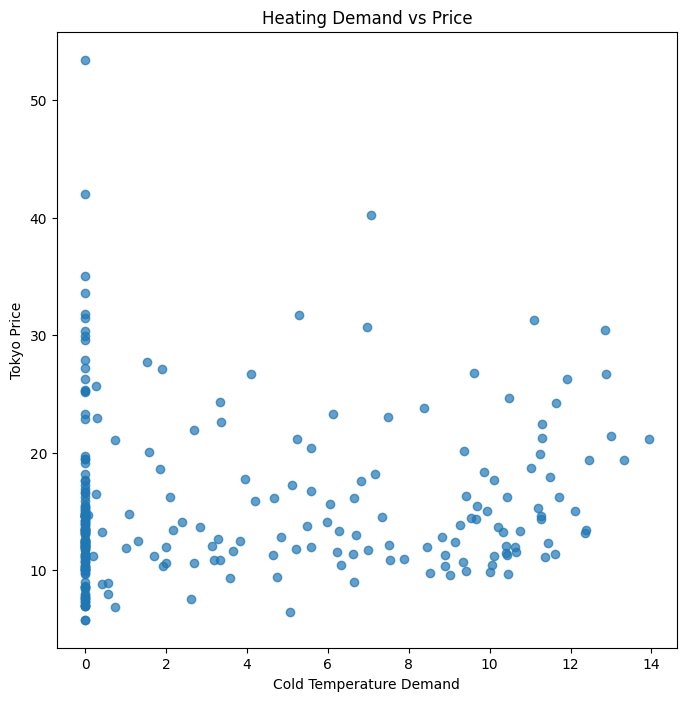

In [21]:
fig, ax = plt.subplots(figsize=(8, 8))

ax.scatter(weekly_base["temp_cold"], weekly_base["tokyo_price"], alpha=0.7)

ax.set_xlabel("Cold Temperature Demand")
ax.set_ylabel("Tokyo Price")

ax.set_title("Heating Demand vs Price")

plt.show()

In [22]:
# 保存
weekly_base.to_csv((PROJECT_DATA_DIR / "features/electricity/weekly_temp_features.csv"))

# Day

In [23]:
tokyo = pd.read_csv((PROJECT_DATA_DIR / "processed/electricity/price_tokyo.csv"))
tokyo["datetime"] = pd.to_datetime(tokyo["datetime"])

tokyo = tokyo.set_index("datetime")
print(tokyo.shape)
tokyo.head()

(175296, 6)


,slot,is_holiday,price,price_scaled,u,x
datetime,,,,,,
2016-04-01 00:00:00,1,False,6.69,6.69,0,0.0
2016-04-01 00:30:00,2,False,6.34,6.34,0,0.0
2016-04-01 01:00:00,3,False,6.34,6.34,0,0.0
2016-04-01 01:30:00,4,False,6.03,6.03,0,0.0
2016-04-01 02:00:00,5,False,6.57,6.57,0,0.0


In [27]:
df_tokyo_slot36 = tokyo[tokyo["slot"] == 36].copy()

print(df_tokyo_slot36.shape)
df_tokyo_slot36.head()

(3652, 6)


,slot,is_holiday,price,price_scaled,u,x
datetime,,,,,,
2016-04-01 17:30:00,36,False,10.03,10.030000,0,0.0
2016-04-02 17:30:00,36,True,7.49,9.084695,0,0.0
2016-04-03 17:30:00,36,True,6.71,8.319092,0,0.0
2016-04-04 17:30:00,36,False,9.64,9.640000,0,0.0
2016-04-05 17:30:00,36,False,8.74,8.740000,0,0.0


In [28]:
from datetime import date
import meteostat as ms

# tokyo
point_tokyo = ms.Point(35.6895, 139.6917)

# tokyo の index から期間取得
start = tokyo.index.min().date()
end = tokyo.index.max().date()

# 周辺観測所
stations = ms.stations.nearby(point_tokyo, limit=4)

# 日次データ取得
ts = ms.daily(stations, start, end)

# 補間
df_weather = ms.interpolate(ts, point_tokyo).fetch()

df_weather.head()

,temp,tmin,tmax,rhum,prcp,snwd,wspd,pres,cldc
time,,,,,,,,,
2016-04-01,11.7,8.3,18.1,63,0.0,<NA>,13.7,1020.5,<NA>
2016-04-02,10.9,7.9,13.3,68,4.1,<NA>,9.1,1026.3,<NA>
2016-04-03,13.0,9.7,16.7,89,<NA>,<NA>,10.1,1023.6,<NA>
2016-04-04,13.9,10.0,21.9,86,6.6,<NA>,13.3,1008.1,<NA>
2016-04-05,10.9,9.7,12.3,77,<NA>,<NA>,8.2,1014.0,<NA>


In [29]:
print(df_weather.shape)

(3652, 9)


抽出する特徴量まとめ

- 快適温度からの差
$$
X_{new} =  ( T_t - \bar{T}_t )^2
$$

- 気温変化
$$
X_{new} = |\Delta T_t|
$$

- 冷暖房需要
$$
X_{new} =
\max(T_t-\bar T,0)
$$

$$
X_{new} =
\max(\bar T - T_t,0)
$$

In [32]:
# -------------------------
# 気温データの特徴量抽出
# -------------------------

weather_features = df_weather.copy()

# 気温カラム名を指定
temp_col = "temp"  # Meteostatの日平均気温

# その時点までの平均気温
weather_features["temp_mean_past"] = weather_features[temp_col].expanding().mean()

# 快適温度からの差
# X_new = (T_t - \bar{T}_t)^2
weather_features["temp_centered_sq"] = (
    weather_features[temp_col] - weather_features["temp_mean_past"]
) ** 2

# 気温変化
# X_new = |ΔT_t|
weather_features["temp_diff_abs"] = weather_features[temp_col].diff().abs()

# 冷暖房需要
comfort_temp = 20

# 暑さ需要
# X_new = max(T_t - \bar{T}, 0)
weather_features["temp_hot"] = (weather_features[temp_col] - comfort_temp).clip(lower=0)

# 寒さ需要
# X_new = max(\bar{T} - T_t, 0)
weather_features["temp_cold"] = (comfort_temp - weather_features[temp_col]).clip(
    lower=0
)

print(weather_features.shape)
weather_features.head()

(3652, 14)


,temp,tmin,tmax,rhum,prcp,snwd,wspd,pres,cldc,temp_mean_past,temp_centered_sq,temp_diff_abs,temp_hot,temp_cold
time,,,,,,,,,,,,,,
2016-04-01,11.7,8.3,18.1,63,0.0,<NA>,13.7,1020.5,<NA>,11.700000,0.0,<NA>,0.0,8.3
2016-04-02,10.9,7.9,13.3,68,4.1,<NA>,9.1,1026.3,<NA>,11.300000,0.16,0.8,0.0,9.1
2016-04-03,13.0,9.7,16.7,89,<NA>,<NA>,10.1,1023.6,<NA>,11.866667,1.284444,2.1,0.0,7.0
2016-04-04,13.9,10.0,21.9,86,6.6,<NA>,13.3,1008.1,<NA>,12.375000,2.325625,0.9,0.0,6.1
2016-04-05,10.9,9.7,12.3,77,<NA>,<NA>,8.2,1014.0,<NA>,12.080000,1.3924,3.0,0.0,9.1


In [34]:
# 保存
weather_features.to_csv((PROJECT_DATA_DIR / "features/electricity/temp_features.csv"))

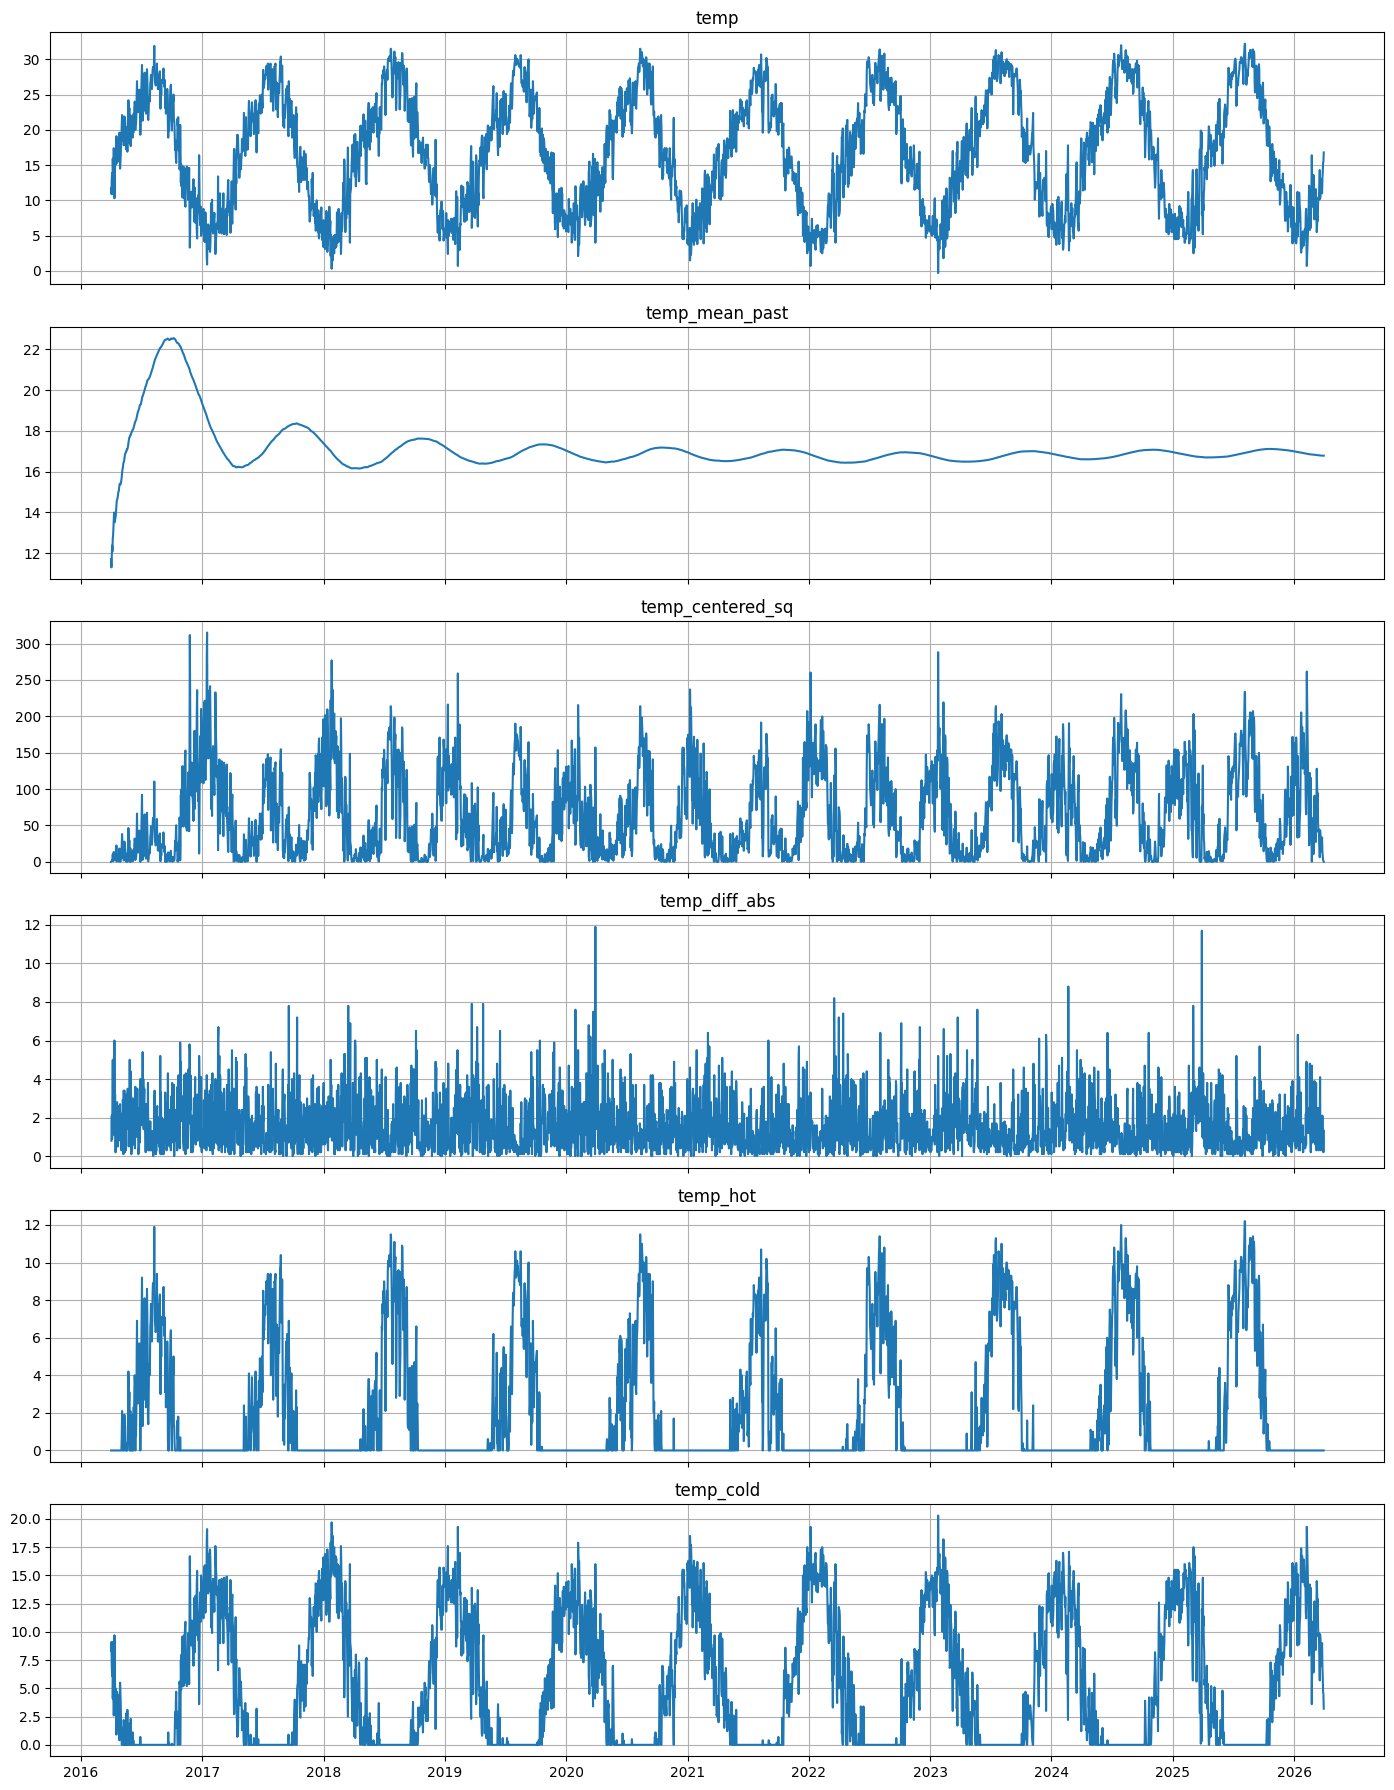

In [ ]:
import matplotlib.pyplot as plt

# プロット対象
plot_cols = [
    "temp",
    "temp_mean_past",
    "temp_centered_sq",
    "temp_diff_abs",
    "temp_hot",
    "temp_cold",
]

# 描画
fig, axes = plt.subplots(nrows=len(plot_cols), ncols=1, figsize=(14, 18), sharex=True)

for ax, col in zip(axes, plot_cols):
    ax.plot(weather_features.index, weather_features[col])
    ax.set_title(col)
    ax.grid(True)

plt.tight_layout()
plt.show()